<a href="https://colab.research.google.com/github/DaniJonesOcean/etc-impacts-great-lakes/blob/dcj_issue20_map/Figure_1_GLR_Map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ETC Impacts on the Great Lakes: Figure 1 Map

This notebook generates the genesis-density overview map used for Figure 1. It loads the labeled storm table from the `processed/` directory, computes a gridded genesis-density field, and plots that field over a North American map with the Great Lakes Region (GLR) highlighted.

This notebook may be easiest to run in Google Colab if Cartopy is not available locally.

## Note on local Cartopy use

This notebook may require Cartopy to download Natural Earth shapefiles the first time it is run locally. On some systems, such as macOS Python installations, SSL certificate issues can prevent those downloads. If that happens, the notebook can be run in Google Colab instead.

In [1]:
# ------------------------------
# 1. Colab setup (only if needed)
# ------------------------------
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install cartopy shapely pyproj

In [2]:
# ------------------------------
# 2. Imports and paths
# ------------------------------
from pathlib import Path
import os
import certifi

# Force Python/urllib to use certifi's CA bundle
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

print("SSL_CERT_FILE =", os.environ.get("SSL_CERT_FILE"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/gdrive")
    BASE_DIR = Path("/content/gdrive/MyDrive/ETC Clustering Paper")
else:
    BASE_DIR = Path.cwd().resolve().parent

PROCESSED_DIR = BASE_DIR / "processed"
FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

CSV_PATH = PROCESSED_DIR / "cfsr_storms_labeled_k2.csv"

print("Base dir:", BASE_DIR)
print("Processed dir:", PROCESSED_DIR)
print("Figure dir:", FIG_DIR)
print("CSV path:", CSV_PATH)

SSL_CERT_FILE = /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/.venv/lib/python3.13/site-packages/certifi/cacert.pem
Base dir: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes
Processed dir: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/processed
Figure dir: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures
CSV path: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/processed/cfsr_storms_labeled_k2.csv


## Load event-level storm table

We use the labeled CFSR storm table generated in the clustering notebook and visualize the geographic distribution of storm genesis locations.

In [3]:
# ------------------------------
# 3. Load data
# ------------------------------
df = pd.read_csv(CSV_PATH)

required_cols = {"lon_gen", "lat_gen"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in input file: {sorted(missing)}")

print("Loaded dataframe shape:", df.shape)
df[["lon_gen", "lat_gen"]].head()

Loaded dataframe shape: (3316, 36)


,lon_gen,lat_gen
0,-86.496468,56.527213
1,-87.342609,34.635036
2,-103.619771,35.571121
3,-87.878904,46.564290
4,-105.355549,43.884595


## Map settings

The map covers the broader North American storm-genesis region and includes a box indicating the Great Lakes Region (GLR).

In [4]:
# ------------------------------
# 4. Map settings
# ------------------------------
lon_min, lon_max = -130, -66
lat_min, lat_max = 24, 65

# Great Lakes Region (GLR) box:
# (lon_left, lat_bottom, width_deg, height_deg)
GLR_BOX = (-92.0, 41.0, 17.0, 8.5)

In [5]:
# ------------------------------
# 5. Plot helpers
# ------------------------------
def setup_ax(ax):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, alpha=0.25)
    ax.add_feature(cfeature.OCEAN, alpha=0.15)
    ax.add_feature(cfeature.LAKES, alpha=0.55)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    gl = ax.gridlines(
        draw_labels=True,
        dms=True,
        x_inline=False,
        y_inline=False,
        color="k",
        alpha=0.25,
        linestyle="--",
        linewidth=0.5,
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}


def smooth2d(H, iters=2):
    K = np.array(
        [
            [1, 2, 1],
            [2, 4, 2],
            [1, 2, 1],
        ],
        dtype=float,
    )
    K /= K.sum()

    A = H.astype(float)
    for _ in range(iters):
        P = np.pad(A, 1, mode="edge")
        A = (
            K[0, 0] * P[:-2, :-2] + K[0, 1] * P[:-2, 1:-1] + K[0, 2] * P[:-2, 2:] +
            K[1, 0] * P[1:-1, :-2] + K[1, 1] * P[1:-1, 1:-1] + K[1, 2] * P[1:-1, 2:] +
            K[2, 0] * P[2:, :-2] + K[2, 1] * P[2:, 1:-1] + K[2, 2] * P[2:, 2:]
        )
    return A

## Generate Figure 1

The plotted field shows genesis density as the fraction of storms per grid cell. The displayed field may optionally be smoothed and clipped in the upper tail for visualization.

In [6]:
# ------------------------------
# 6. Figure 1 function
# ------------------------------
def plot_fig1_glr_overview(
    df: pd.DataFrame,
    add_density: bool = True,
    dlon: float = 0.5,
    dlat: float = 0.5,
    smooth_iters: int = 2,
    clip_q: float = 0.95,
    normalize: bool = True,
    fname: str = "fig1_glr_overview_density_1p5deg",
):
    d = df.dropna(subset=["lon_gen", "lat_gen"]).copy()

    fig = plt.figure(figsize=(12, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())
    # Cartopy may need to download Natural Earth shapefiles the first time
    # these features are used. If local SSL/certificate issues prevent that,
    # run this notebook in Google Colab instead.
    setup_ax(ax)

    if add_density:
        lon_bins = np.arange(lon_min, lon_max + dlon, dlon)
        lat_bins = np.arange(lat_min, lat_max + dlat, dlat)

        H, xedges, yedges = np.histogram2d(
            d["lon_gen"],
            d["lat_gen"],
            bins=[lon_bins, lat_bins],
        )

        # Rows correspond to latitude, columns to longitude
        H = H.T

        if normalize and H.sum() > 0:
            H = H / H.sum()

        Hs = smooth2d(H, iters=smooth_iters)

        if np.any(Hs > 0):
            upper = np.quantile(Hs[Hs > 0], clip_q)
            Hplot = np.clip(Hs, 0, upper)
        else:
            Hplot = Hs

        X, Y = np.meshgrid(xedges, yedges)

        pm = ax.pcolormesh(
            X,
            Y,
            Hplot,
            transform=ccrs.PlateCarree(),
            shading="auto",
            alpha=1.0,
            cmap="Purples",
            vmin=0,
        )

        cbar = fig.colorbar(pm, ax=ax, shrink=0.85, pad=0.02)
        cbar.set_label(f"Genesis density (fraction per {dlon:.2f}° × {dlat:.2f}° grid cell)")

    rect = Rectangle(
        (GLR_BOX[0], GLR_BOX[1]),
        GLR_BOX[2],
        GLR_BOX[3],
        fill=False,
        linewidth=2.5,
        edgecolor="k",
        transform=ccrs.PlateCarree(),
    )
    ax.add_patch(rect)

    ax.text(
        GLR_BOX[0] + 0.7,
        GLR_BOX[1] + GLR_BOX[3] - 0.8,
        "Great Lakes Region (GLR)",
        fontsize=12,
        weight="bold",
        transform=ccrs.PlateCarree(),
        bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=2.5),
    )

    ax.set_title(
        f"Genesis density (fraction per {dlon:.2f}° × {dlat:.2f}° grid cell)",
        fontsize=14,
    )

    fig.tight_layout()

    png_path = FIG_DIR / f"{fname}.png"
    pdf_path = FIG_DIR / f"{fname}.pdf"

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    return png_path, pdf_path

/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/.venv/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/.venv/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/.venv/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/.venv/lib/python3.13/site-packages/cartopy/io/__init__.py:242:

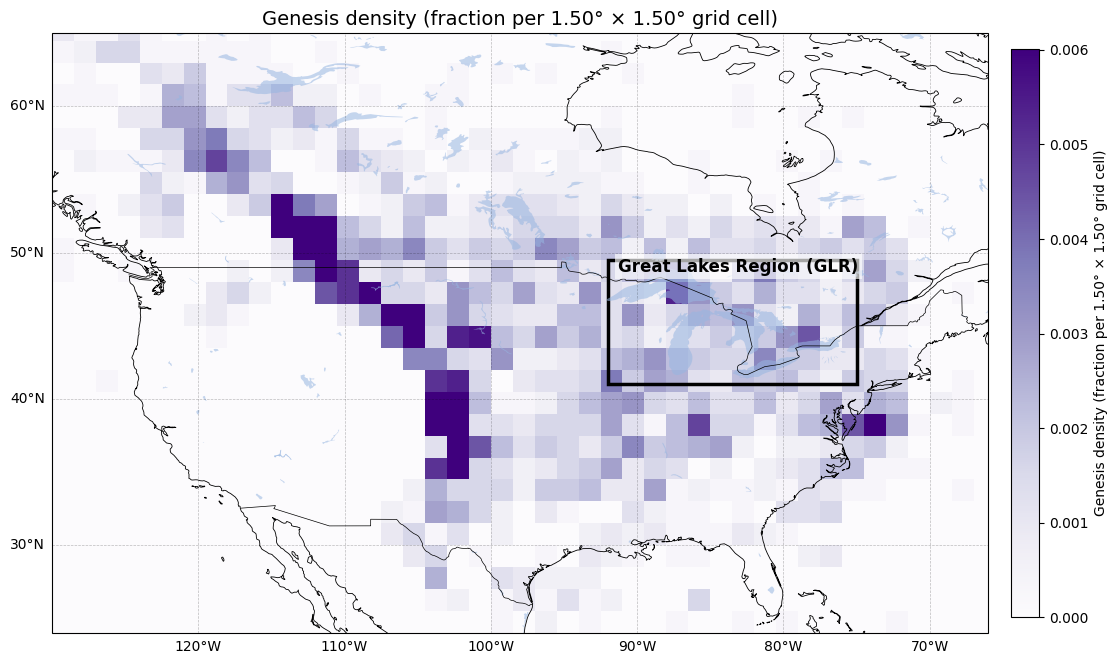

Saved PNG: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig1_glr_overview_density_1p5deg.png
Saved PDF: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig1_glr_overview_density_1p5deg.pdf


In [7]:
# ------------------------------
# 7. Run and save Figure 1
# ------------------------------
png_path, pdf_path = plot_fig1_glr_overview(
    df,
    add_density=True,
    dlon=1.5,
    dlat=1.5,
    normalize=True,
    clip_q=0.97,
    smooth_iters=0,
    fname="fig1_glr_overview_density_1p5deg",
)

print("Saved PNG:", png_path)
print("Saved PDF:", pdf_path)

## Summary

This notebook generates the Figure 1 genesis-density overview map and saves both PNG and PDF versions to the `figures/` directory.